In [1]:
# Install cmapPy the official Broad Institute library for reading .gctx files because pandas doesnyt work here becuse in this data there are scientific tables that pandas cant read.
!pip install cmapPy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 8.4 MB/s eta 0:00:00


In [2]:
from cmapPy.pandasGEXpress.parse import parse # parse is used to raed gtx files and cpampy is a package
import pandas as pd
import numpy as np

print("cmapPy is ready!")# for my confirmation
print("pandas version:", pd.__version__)

cmapPy is ready!
pandas version: 2.2.2


In [3]:
# Download the cell-line metadata file from the same S3 folder Marouen used , it ia called galenAI it is a folder where metadata sits
!curl -O https://cmapreg.s3.amazonaws.com/galenAI/cellinfo_beta.txt

# Peek at the first 3 lines to see if it really downloaded
!head -3 cellinfo_beta.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   263    0   263    0     0    343      0 --:--:-- --:--:-- --:--:--   343
<?xml version="1.0" encoding="UTF-8"?>
<Error><Code>AccessDenied</Code><Message>Access Denied</Message><RequestId>J1M3091BRVVGB67K</RequestId><HostId>UKbtLmDJ1XZ5I+3jNqHhbJ54LPILWKSvj1eHB8f4Ip5u6/w5gcCXEQwJ58hooALYY/M2htLdKBIubjDR0wpwcLK06YP88/tP</HostId></Error>

In [6]:
# The metadata's official public home — the clue.io LINCS 2020 build folder
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/cellinfo_beta.txt#metadata downloading

# Peek at the first 3 lines to confirm it's real it will help me in understabdif data
!head -3 cellinfo_beta.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 37979  100 37979    0     0  36621      0  0:00:01  0:00:01 --:--:-- 36659
cell_iname	cellosaurus_id	donor_age	donor_age_death	donor_disease_age_onset	doubling_time	growth_medium	provider_catalog_id	feature_id	cell_type	donor_ethnicity	donor_sex	donor_tumor_phase	cell_lineage	primary_disease	subtype	provider_name	growth_pattern	ccle_name	cell_alias
1HAE	""	""			""	""	""	""	normal	Unknown	Unknown	Unknown	unknown	unknown	normal fibroblast sample	""	unknown	""	""
AALE	""	""			""	""	""	""	normal	Unknown	Unknown	Unknown	unknown	unknown	normal epithelium sample	""	unknown	""	""


%total = file total size = 37979 bytes 37 kB

%Received = how much it receives 100% means full download

% Xferd = how much it uploads

average speed Dload = 36621 bytes/sec

**cell_iname = cell line internalname eg 1HAE, AALE** eg IHAE name of cancer cell
cellosaurus_id  = UNIQUE ID cell line global registry
donar_age = donor when cell line exists
donor_age_death = donor age at death time

donor_disease_age_onset = donor age when disease started
doubling_time = time taken by cell to double in number **bold text**
growth_medium = liquid food/medium used to grow cell
provider_catalog_id = vendor catalog number (eg ATCC ID)
feature_id = internal feature identifier
cell_type = type of cell, eg normal or tumor
donor_ethnicity = donor ethnicity / background
**donor_sex = donor sex (Male / Female / Unknown), important for project**
donor_tumor_phase = phase of tumor in donor
cell_lineage = tissue origin of cell, eg lung, breast
**primary_disease = main disease name (eg cancer type)**
subtype = disease subtype
provider_name = company/lab that gave the cell line
growth_pattern = how cells grow (adherent or suspension)
ccle_name = name in CCLE (Cancer Cell Line Encyclopedia)
cell_alias = other names of the cell line

Sample rows:
1HAE = normal fibroblast sample, donor_sex = Unknown, most fields empty
AALE = normal epithelium sample, donor_sex = Unknown, most fields empty
"" = empty value = info not available (missing data)

Note: Many rows have donor_sex = Unknown. Need to filter and keep only Male and Female rows for SexDifferences analysis. **bold text**

# grab the other three metadata files

In [7]:
# Gene metadata — gene IDs to readable gene names
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/geneinfo_beta.txt #for gene names +id's

# Compound metadata — details about each drug
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/compoundinfo_beta.txt #for drug detail

# Signature metadata — links every experiment to its cell line + drug + dose + time
!curl -O https://s3.amazonaws.com/macchiato.clue.io/builds/LINCS2020/siginfo_beta.txt # 1.2 million experiement

# List what we now have, with sizes
!ls -lh *.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1114k  100 1114k    0     0   543k      0  0:00:02  0:00:02 --:--:--  543k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 4522k  100 4522k    0     0  1847k      0  0:00:02  0:00:02 --:--:-- 1847k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  443M  100  443M    0     0  14.8M      0  0:00:29  0:00:29 --:--:-- 16.6M
-rw-r--r-- 1 root root  38K May 23 08:42 cellinfo_beta.txt
-rw-r--r-- 1 root root 4.5M May 23 09:19 compoundinfo_beta.txt
-rw-r--r-- 1 root root 1.1M May 23 09:19 geneinfo_beta.txt
-rw-r--r-- 1 root root 444M May 23 09:20 siginfo_beta.txt


| File | Size | What's inside |
|------|------|---------------|
| cellinfo_beta.txt | 38 KB | The cell lines + donor sex |
| geneinfo_beta.txt | 1.1 MB | ~12,000 genes |
| compoundinfo_beta.txt | 4.5 MB | ~33,000 drugs |
| siginfo_beta.txt | 444 MB | ~1.2 million experiment records |

In [8]:
# Load the cell-line metadata into a pandas DataFrame
# sep='\t'  ->  columns are separated by TABS, not commas
cell = pd.read_csv('cellinfo_beta.txt', sep='\t')

# How big is our table?  (rows, columns)
print("Shape:", cell.shape)

# What columns do we have?
print("\nColumns:")
print(list(cell.columns))

# Show the first 5 rows
cell.head()

Shape: (240, 20)

Columns:
['cell_iname', 'cellosaurus_id', 'donor_age', 'donor_age_death', 'donor_disease_age_onset', 'doubling_time', 'growth_medium', 'provider_catalog_id', 'feature_id', 'cell_type', 'donor_ethnicity', 'donor_sex', 'donor_tumor_phase', 'cell_lineage', 'primary_disease', 'subtype', 'provider_name', 'growth_pattern', 'ccle_name', 'cell_alias']


,cell_iname,cellosaurus_id,donor_age,donor_age_death,donor_disease_age_onset,doubling_time,growth_medium,provider_catalog_id,feature_id,cell_type,donor_ethnicity,donor_sex,donor_tumor_phase,cell_lineage,primary_disease,subtype,provider_name,growth_pattern,ccle_name,cell_alias
0,1HAE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,Unknown,Unknown,Unknown,unknown,unknown,normal fibroblast sample,NaN,unknown,NaN,NaN
1,AALE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,normal,Unknown,Unknown,Unknown,unknown,unknown,normal epithelium sample,NaN,unknown,NaN,NaN
2,AG06263_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor,Unknown,Unknown,Unknown,unknown,unknown,unknown,NaN,unknown,NaN,NaN
3,AG06840_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor,Unknown,Unknown,Unknown,unknown,unknown,unknown,NaN,unknown,NaN,NaN
4,AG078N1_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tumor,Unknown,Unknown,Unknown,unknown,unknown,unknown,NaN,unknown,NaN,NaN


In [9]:
#  how many cell lines came from male vs female donors?
print("Donor sex breakdown:")# donor here means the cell line belongs to
print(cell['donor_sex'].value_counts()) # unique value how many times

#  are these normal cells or tumour cells?
print("\nCell type breakdown:")
print(cell['cell_type'].value_counts())

Donor sex breakdown:
donor_sex
Unknown    99
F          78
M          63
Name: count, dtype: int64

Cell type breakdown:
cell_type
tumor     188
pool       29
normal     23
Name: count, dtype: int64


In [10]:
# Load the signature (experiment) metadata — big file, give it ~30-60 seconds
sig = pd.read_csv('siginfo_beta.txt', sep='\t')

print("Shape:", sig.shape)
print("\nColumns:")
print(list(sig.columns))

sig.head()

/tmp/ipykernel_1558/2501463265.py:2: DtypeWarning: Columns (0,3,4,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  sig = pd.read_csv('siginfo_beta.txt', sep='\t')


Shape: (1201944, 37)

Columns:
['bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_itime', 'pert_time', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'nsample', 'cc_q75', 'ss_ngene', 'tas', 'pct_self_rank_q25', 'wt', 'median_recall_rank_spearman', 'median_recall_rank_wtcs_50', 'median_recall_score_spearman', 'median_recall_score_wtcs_50', 'batch_effect_tstat', 'batch_effect_tstat_pct', 'is_hiq', 'qc_pass', 'pert_id', 'sig_id', 'pert_type', 'cell_iname', 'det_wells', 'det_plates', 'distil_ids', 'build_name', 'project_code', 'cmap_name', 'is_exemplar_sig', 'is_ncs_sig', 'is_null_sig']


,bead_batch,nearest_dose,pert_dose,pert_dose_unit,pert_idose,pert_itime,pert_time,pert_time_unit,cell_mfc_name,pert_mfc_id,...,cell_iname,det_wells,det_plates,distil_ids,build_name,project_code,cmap_name,is_exemplar_sig,is_ncs_sig,is_null_sig
0,b17,NaN,100.0,ug/ml,100 ug/ml,336 h,336.0,h,N8,BRD-U44432129,...,NAMEC8,H05|H06|H07|H08,MET001_N8_XH_X1_B17,MET001_N8_XH_X1_B17:H05|MET001_N8_XH_X1_B17:H0...,NaN,MET,BRD-U44432129,0,0.0,0.0
1,b15,10.0,10.0,uM,10 uM,3 h,3.0,h,A549,BRD-K81418486,...,A549,L04|L08|L12,ABY001_A549_XH_X1_B15,ABY001_A549_XH_X1_B15:L04|ABY001_A549_XH_X1_B1...,NaN,ABY,vorinostat,0,1.0,0.0
2,b15,2.5,2.5,uM,2.5 uM,24 h,24.0,h,HT29,BRD-K70511574,...,HT29,E18|E22,ABY001_HT29_XH_X1_B15,ABY001_HT29_XH_X1_B15:E18|ABY001_HT29_XH_X1_B1...,NaN,ABY,HMN-214,0,1.0,0.0
3,b18,10.0,10.0,uM,10 uM,3 h,3.0,h,HME1,BRD-K81418486,...,HME1,F19,LTC002_HME1_3H_X1_B18,LTC002_HME1_3H_X1_B18:F19,NaN,LTC,vorinostat,0,0.0,0.0
4,b15,10.0,10.0,uM,10 uM,3 h,3.0,h,H1975,BRD-A61304759,...,H1975,P01|P05|P09,ABY001_H1975_XH_X1_B15,ABY001_H1975_XH_X1_B15:P01|ABY001_H1975_XH_X1_...,NaN,ABY,tanespimycin,0,0.0,0.0


In [11]:
# Keep only the cell-line columns we need
cell_small = cell[['cell_iname', 'donor_sex', 'cell_type', 'cell_lineage', 'primary_disease']]

# THE JOIN — attach donor sex (and more) to every signature, matched on cell_iname
sig = sig.merge(cell_small, on='cell_iname', how='left')

print("Shape after join:", sig.shape)

# Now: how does donor sex split across ALL ~1.2M experiments?
print("\nDonor sex across all signatures:")
print(sig['donor_sex'].value_counts(dropna=False))

Shape after join: (1201944, 41)

Donor sex across all signatures:
donor_sex
F          536607
M          460942
Unknown    181976
NaN         22419
Name: count, dtype: int64


In [20]:
# What perturbation types exist in the logbook?
print("Perturbation types:")
print(sig['pert_type'].value_counts())

# Marouen's file is drug treatments only -> keep just 'trt_cp'
sig_cp = sig[sig['pert_type'] == 'trt_cp'].copy()
print("\nDrug-treatment signatures only:", sig_cp.shape)

# Sex breakdown among the drug signatures


# - Big file (444 MB), takes ~30-60 seconds to load
# - Each row = one experiment (drug + cell
print("\nDonor sex (drug signatures):")
print(sig_cp['donor_sex'].value_counts(dropna=False))

Perturbation types:
pert_type
trt_cp             720216
trt_sh             177263
trt_xpr            140945
ctl_vehicle         39448
trt_sh.cgs          36720
trt_oe              34171
trt_sh.css          24368
ctl_vector          14969
trt_lig              7546
ctl_untrt            5332
trt_aby               575
trt_si                162
ctl_vector.cns        137
ctl_vehicle.cns        61
ctl_untrt.cns          30
ctl_x                   1
Name: count, dtype: int64

Drug-treatment signatures only: (720216, 41)

Donor sex (drug signatures):
donor_sex
F          341977
M          254140
Unknown    124099
Name: count, dtype: int64


In [16]:
# Keep only experiments with a known sex (drop 'Unknown')
sig_known = sig_cp[sig_cp['donor_sex'].isin(['M', 'F'])].copy()
print("Experiments with known sex:", sig_known.shape)

# How many different drugs and different cell lines do we have?
print("Different drugs:", sig_known['cmap_name'].nunique())
print("Different cell lines:", sig_known['cell_iname'].nunique())

Experiments with known sex: (596117, 41)
Different drugs: 32917
Different cell lines: 136


In [17]:
# For each drug: how many different cell lines of each sex was it tested in?
drug_summary = sig_known.pivot_table(
    index='cmap_name',
    columns='donor_sex',
    values='cell_iname',
    aggfunc='nunique',
    fill_value=0
)

# Add a 'total' column (male + female cell lines)
drug_summary['total'] = drug_summary['F'] + drug_summary['M']

# Keep only drugs tested in at least 5 male AND 5 female cell lines
good_drugs = drug_summary[(drug_summary['M'] >= 5) & (drug_summary['F'] >= 5)]

# Sort: most-tested drugs at the top
good_drugs = good_drugs.sort_values('total', ascending=False)

print("Drugs tested in >=5 male AND >=5 female cell lines:", good_drugs.shape[0])
print("\nTop 15 best-tested drugs:")
print(good_drugs.head(15))

Drugs tested in >=5 male AND >=5 female cell lines: 2408

Top 15 best-tested drugs:
donor_sex      F   M  total
cmap_name                  
selumetinib   65  52    117
vorinostat    63  53    116
tozasertib    65  51    116
NVP-BEZ235    64  50    114
fostamatinib  62  49    111
bortezomib    59  49    108
olaparib      60  47    107
BI-2536       60  47    107
ABT-737       60  46    106
troglitazone  57  48    105
NVP-AUY922    57  46    103
calcitriol    55  47    102
AS-605240     56  46    102
vemurafenib   56  45    101
PI-103        55  45    100


In [18]:
# Our study drug
drug = 'vorinostat'

# All vorinostat experiments with known sex
vori = sig_known[sig_known['cmap_name'] == drug].copy()
print("Total vorinostat experiments:", vori.shape[0])

# Split into male and female
vori_M = vori[vori['donor_sex'] == 'M']
vori_F = vori[vori['donor_sex'] == 'F']
print("Male experiments:", vori_M.shape[0])
print("Female experiments:", vori_F.shape[0])

# Save the signature list (our 'shopping list' for the big file)
vori[['sig_id','cell_iname','donor_sex','pert_idose','pert_itime']].to_csv(
    'vorinostat_signatures.csv', index=False)
print("\nSaved: vorinostat_signatures.csv")

Total vorinostat experiments: 2641
Male experiments: 1180
Female experiments: 1461

Saved: vorinostat_signatures.csv


In [19]:
# nbow i am Downloading the big CMAP data file (~36 GB of gene numbers)

!curl -O https://cmapreg.s3.amazonaws.com/galenAI/level5_beta_trt_cp_n720216x12328.gctx

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 33.0G  100 33.0G    0     0  11.7M      0  0:47:53  0:47:53 --:--:-- 12.0M


In [21]:
# The big data file
gctx_file = 'level5_beta_trt_cp_n720216x12328.gctx'

# Confirm it downloaded fully (should say ~33G)
!ls -lh {gctx_file}

# Read ONLY the column labels — fast, no gene numbers loaded yet
col_meta = parse(gctx_file, col_meta_only=True)
print("Signatures inside the data file:", col_meta.shape[0])

# Check: are our vorinostat experiments actually in the file?
gctx_sigs = set(col_meta.index)
vori_sigs = [s for s in vori['sig_id'] if s in gctx_sigs]
print("Vorinostat experiments found in the file:", len(vori_sigs), "of", len(vori))

-rw-r--r-- 1 root root 34G May 23 10:27 level5_beta_trt_cp_n720216x12328.gctx


/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


Signatures inside the data file: 720216
Vorinostat experiments found in the file: 2641 of 2641


In [22]:
# Pull ONLY the 2,641 vorinostat columns out of the 34 GB file
# This reads from disk — it may take 1-3 minutes. Be patient.
vori_data = parse(gctx_file, cid=vori_sigs)

# The gene-expression matrix: genes (rows) x experiments (columns)
expr = vori_data.data_df
print("Vorinostat expression matrix:", expr.shape)
print("(rows = genes, columns = experiments)")

# Peek at a small corner
expr.iloc[:5, :4]

/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/usr/local/lib/python3.12/dist-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


Vorinostat expression matrix: (12328, 2641)
(rows = genes, columns = experiments)


cid,ABY001_A375_XH:BRD-K81418486:0.625:24,ABY001_A375_XH:BRD-K81418486:0.625:3,ABY001_A375_XH:BRD-K81418486:10:24,ABY001_A375_XH:BRD-K81418486:10:3
rid,,,,
10,0.973752,1.052700,-0.448198,0.486499
100,-0.461948,-0.057849,1.687490,0.446671
1000,0.363617,0.094771,-3.216104,-0.462903
10000,1.016755,-0.275497,-2.482721,-0.238916
10001,-0.457693,-0.859845,0.460262,0.204104


In [23]:
# Build a lookup: experiment ID  ->  sex (M or F)
sex_map = vori.set_index('sig_id')['donor_sex']

# Sort the 2,641 columns into two piles
male_cols   = [s for s in expr.columns if sex_map[s] == 'M']
female_cols = [s for s in expr.columns if sex_map[s] == 'F']
print("Male experiments:  ", len(male_cols))
print("Female experiments:", len(female_cols))

# Two separate matrices
male_expr   = expr[male_cols]
female_expr = expr[female_cols]
print("Male matrix:  ", male_expr.shape)
print("Female matrix:", female_expr.shape)

Male experiments:   1180
Female experiments: 1461
Male matrix:   (12328, 1180)
Female matrix: (12328, 1461)


In [24]:
from scipy.stats import mannwhitneyu

results = []
for gene in expr.index:
    male_vals   = male_expr.loc[gene].values
    female_vals = female_expr.loc[gene].values
    stat, p = mannwhitneyu(male_vals, female_vals, alternative='two-sided')
    results.append({
        'gene_id'    : gene,
        'male_mean'  : male_vals.mean(),
        'female_mean': female_vals.mean(),
        'difference' : male_vals.mean() - female_vals.mean(),
        'p_value'    : p
    })

res = pd.DataFrame(results)
print("Genes tested:", len(res))
res.head()

Genes tested: 12328


,gene_id,male_mean,female_mean,difference,p_value
0,10,0.374599,0.275416,0.099182,0.023924
1,100,0.603168,0.800740,-0.197572,0.014273
2,1000,-0.145286,-0.003056,-0.142229,0.000010
3,10000,0.335458,0.147450,0.188008,0.000574
4,10001,-0.099072,-0.122255,0.023183,0.518150


In [26]:
from statsmodels.stats.multitest import multipletests

# Benjamini-Hochberg FDR correction — adjust for running 12,328 tests
res['p_adj'] = multipletests(res['p_value'], method='fdr_bh')[1]

# Significant genes = honest (adjusted) p-value below 0.05
sig_genes = res[res['p_adj'] < 0.05].copy()
sig_genes = sig_genes.sort_values('p_adj')

print("Total genes tested:", len(res))
print("Significant sex-difference genes (FDR < 0.05):", len(sig_genes))
print("\nTop 15 strongest sex-difference genes:")
print(sig_genes.head(15))

Total genes tested: 12328
Significant sex-difference genes (FDR < 0.05): 6877

Top 15 strongest sex-difference genes:
      gene_id  male_mean  female_mean  difference       p_value         p_adj
1554     1514  -1.302663     0.335575   -1.638238  1.042622e-62  1.285345e-58
3085    25805   2.499600     0.722543    1.777057  1.178280e-58  7.262918e-55
3967     2941   0.437311     1.164593   -0.727282  2.572905e-48  1.057293e-44
4060    29937  -0.403103     0.361506   -0.764608  1.061179e-47  3.270553e-44
3466    26872  -1.116890    -0.176929   -0.939961  5.710422e-45  1.407962e-41
11178    8714  -0.366801     0.284275   -0.651077  1.061626e-44  2.181287e-41
9820     7802   0.986303     0.243259    0.743044  7.448131e-44  1.311722e-40
2006     2039  -0.556544     0.059792   -0.616336  1.039597e-42  1.602018e-39
1573     1534   0.376720    -0.979549    1.356268  3.333337e-42  4.565931e-39
3361    26292   1.216826     0.422281    0.794545  4.801427e-42  5.919199e-39
3114    25842  -0.318377

In [27]:
# A p-value says "IS there a difference" — not "is it BIG".
# With 2,641 experiments the test is very powerful, so we ALSO require a large effect.

# 'difference' = effect size (male mean - female mean, in z-score units)
strong = res[(res['p_adj'] < 0.05) & (res['difference'].abs() > 1.0)].copy()
strong = strong.sort_values('p_adj')

print("Significant genes (FDR < 0.05):              ", (res['p_adj'] < 0.05).sum())
print("Significant AND large effect (|diff| > 1.0): ", len(strong))
print("\nTop 15 genes that truly stand out:")
print(strong.head(15))

Significant genes (FDR < 0.05):               6877
Significant AND large effect (|diff| > 1.0):  20

Top 15 genes that truly stand out:
      gene_id  male_mean  female_mean  difference       p_value         p_adj
1554     1514  -1.302663     0.335575   -1.638238  1.042622e-62  1.285345e-58
3085    25805   2.499600     0.722543    1.777057  1.178280e-58  7.262918e-55
1573     1534   0.376720    -0.979549    1.356268  3.333337e-42  4.565931e-39
1840     1848   1.492619     0.256507    1.236111  8.279051e-41  7.851088e-38
9       10007  -2.246371    -1.050267   -1.196104  3.464110e-39  2.512091e-36
8012     5831  -2.109517    -0.838393   -1.271125  5.473363e-39  3.748645e-36
3331     2625   0.727841    -0.522192    1.250033  4.333505e-37  2.225977e-34
6135    51635  -1.354301    -0.057558   -1.296744  2.439310e-31  7.517952e-29
1864     1891  -1.940951    -0.728900   -1.212051  2.889402e-31  8.687939e-29
3682     2745   1.888631     3.589691   -1.701060  3.828188e-28  7.374047e-26
11201 

In [28]:
# Load the gene-name dictionary
genes = pd.read_csv('geneinfo_beta.txt', sep='\t')
print("Shape:", genes.shape)
print("Columns:", list(genes.columns))
genes.head(3)

Shape: (12328, 7)
Columns: ['gene_id', 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space']


,gene_id,gene_symbol,ensembl_id,gene_title,gene_type,src,feature_space
0,750,GAS8-AS1,ENSG00000221819,GAS8 antisense RNA 1,ncRNA,NCBI,inferred
1,6315,ATXN8OS,NaN,ATXN8 opposite strand lncRNA,ncRNA,NCBI,inferred
2,7503,XIST,ENSG00000229807,X inactive specific transcript,ncRNA,NCBI,inferred


In [29]:
# Keep just the useful columns from the catalogue
gene_names = genes[['gene_id', 'gene_symbol', 'gene_title', 'gene_type']].copy()

# Safety: make gene_id the SAME type (text) on both sides
strong['gene_id']     = strong['gene_id'].astype(str)
gene_names['gene_id'] = gene_names['gene_id'].astype(str)

# JOIN the names onto your 20 standout genes
strong_named = strong.merge(gene_names, on='gene_id', how='left')
strong_named = strong_named.sort_values('p_adj')

# Show the readable result
print("Your 20 standout sex-difference genes for vorinostat:\n")
print(strong_named[['gene_symbol','gene_title','difference','p_adj']].to_string(index=False))

Your 20 standout sex-difference genes for vorinostat:

gene_symbol                                   gene_title  difference        p_adj
       CTSL                                  cathepsin L   -1.638238 1.285345e-58
      BAMBI     BMP and activin membrane bound inhibitor    1.777057 7.262918e-55
     CYB561                              cytochrome b561    1.356268 4.565931e-39
      DUSP6               dual specificity phosphatase 6    1.236111 7.851088e-38
     GNPDA1          glucosamine-6-phosphate deaminase 1   -1.196104 2.512091e-36
      PYCR1          pyrroline-5-carboxylate reductase 1   -1.271125 3.748645e-36
      GATA3                       GATA binding protein 3    1.250033 2.225977e-34
      DHRS7                    dehydrogenase/reductase 7   -1.296744 7.517952e-29
       ECH1                        enoyl-CoA hydratase 1   -1.212051 8.687939e-29
       GLRX                                 glutaredoxin   -1.701060 7.374047e-26
       CBR3                         carbony

In [30]:
# Add gene names to the FULL results table (all 12,328 genes)
res['gene_id'] = res['gene_id'].astype(str)
res_named = res.merge(gene_names, on='gene_id', how='left')

# Save both tables as CSV files
res_named.to_csv('vorinostat_all_genes_results.csv', index=False)
strong_named.to_csv('vorinostat_top20_sex_genes.csv', index=False)

print("Saved:")
print(" - vorinostat_all_genes_results.csv  (all 12,328 genes)")
print(" - vorinostat_top20_sex_genes.csv    (the 20 standout genes)")

Saved:
 - vorinostat_all_genes_results.csv  (all 12,328 genes)
 - vorinostat_top20_sex_genes.csv    (the 20 standout genes)


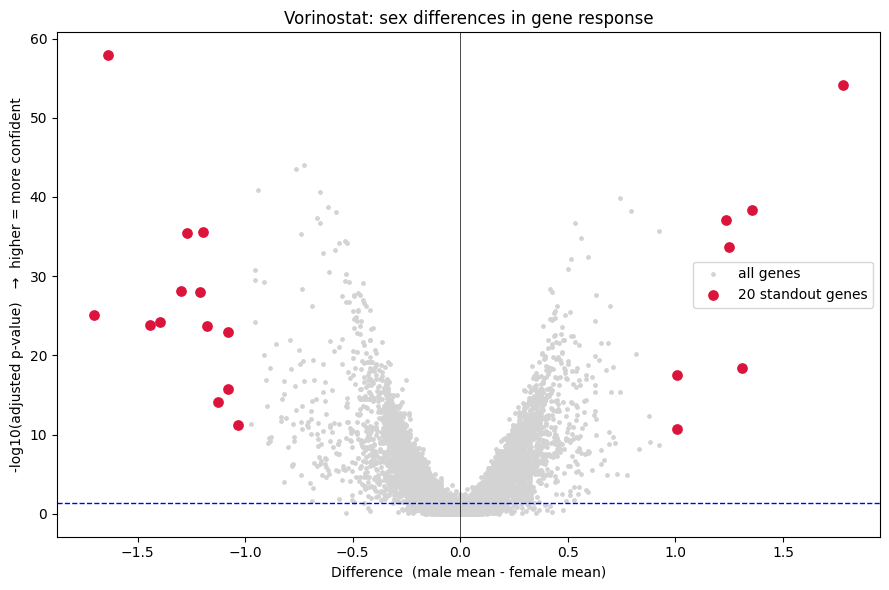

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9,6))

# all genes in grey
neglog_p = -np.log10(res_named['p_adj'].clip(lower=1e-300))
plt.scatter(res_named['difference'], neglog_p, s=6, color='lightgray', label='all genes')

# the 20 standout genes in red
strong_neglog = -np.log10(strong_named['p_adj'].clip(lower=1e-300))
plt.scatter(strong_named['difference'], strong_neglog, s=45, color='crimson', label='20 standout genes')

plt.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Difference  (male mean - female mean)')
plt.ylabel('-log10(adjusted p-value)   →  higher = more confident')
plt.title('Vorinostat: sex differences in gene response')
plt.legend()
plt.tight_layout()
plt.savefig('volcano_vorinostat.png', dpi=150)
plt.show()

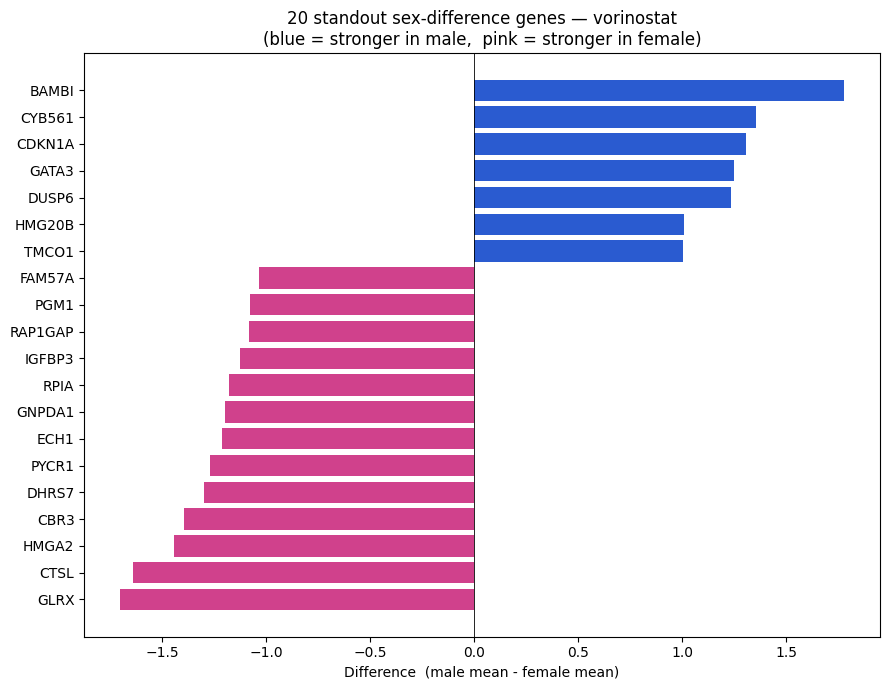

In [32]:
# Bar chart of the 20 standout genes
plt.figure(figsize=(9,7))

d = strong_named.sort_values('difference')
colors = ['#d0418c' if x < 0 else '#2a5bd0' for x in d['difference']]  # pink=female, blue=male

plt.barh(d['gene_symbol'], d['difference'], color=colors)
plt.axvline(0, color='black', linewidth=0.6)
plt.xlabel('Difference  (male mean - female mean)')
plt.title('20 standout sex-difference genes — vorinostat\n(blue = stronger in male,  pink = stronger in female)')
plt.tight_layout()
plt.savefig('top20_genes_vorinostat.png', dpi=150)
plt.show()

In [33]:
from google.colab import files
files.download('volcano_vorinostat.png')
files.download('top20_genes_vorinostat.png')
files.download('vorinostat_top20_sex_genes.csv')
files.download('vorinostat_all_genes_results.csv')
files.download('vorinostat_signatures.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>